<a href="https://colab.research.google.com/github/Reben80/Data201/blob/main/DATA_201_Week_5A_Demo_Resampling_for_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DATA 201 WEEK 4A
##Resampling Methods for Inference: Estimation

This tutorial includes material adapted from [Resampling Statitics](https://) by Luke Chang.


Most the statistics you have learned in introductory statistics are based on parametric statistics and assume a normal distribution. However, in applied data analysis these assumptions are rarely met.

Non-parametric resampling statistics and they are amenable to most types of modeling applications such as fitting abstract computational models, multivariate predictive models, and hypothesis testing.

**Bootstrap Resampling**: Randomly sampling with replacement to create many different datasets

**Jackknife Resampling**: Systematically leaving out one observation at a time.



In this tutorial, we will focus on the bootstrap and jackknife resampling. Jackknifing and bootstrapping are both used to calculate the variability of an estimator and often provide numerically similar results.

#I. Bootstrap


To see how this work, first let’s create population data by sampling from a normal distribution. For this simulation, we will assume that there are 10,000 participants in the population that are normally distributed N(50, 10)


Question:  What does the notation N(50, 10) means?

Population Mean: 50.0
Population Std: 10.0


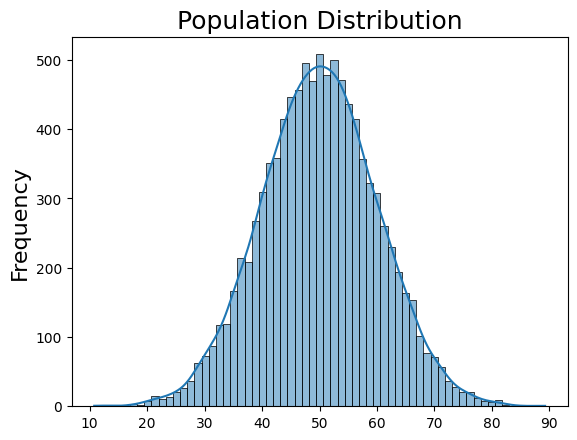

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

mean = 50
std = 10
population_n = 10000

# Set seed for reproducibility
np.random.seed(42)

#Generate a random set of data based on the given parameters.
population = mean + np.random.randn(population_n)*std

#Plot the simulated dataset
sns.histplot(population, kde=True, label='Population')
plt.title('Population Distribution', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Population Mean: {np.mean(population):.3}')
print(f'Population Std: {np.std(population):.3}')

Syntax note:

The letter f at the beginning of the string literal in the code snippet denotes a f-string (formatted string literal) in Python.

Purpose of the f-string

The f-string allows you to embed Python expressions directly inside a string by placing them within curly braces {}. It provides a concise and readable way to build strings that contain variables or the results of function calls.

Now, let’s run a single experiment where we randomly sample n participants from the population. You can see that the mean and standard deviation of this distribution are fairly close to the population even though we are not full sampling the distribution.

Sample Mean: 49.1
Sample Std: 10.9


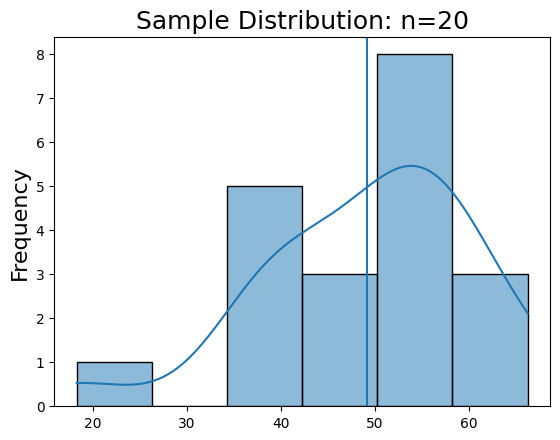

In [13]:
sample_n = 20
sample = np.random.choice(population, size=sample_n, replace=False)

sns.histplot(sample, kde=True, label='Single Sample')
plt.axvline(x=np.mean(sample), ymin=0, ymax=1, linestyle='-')
plt.title(f'Sample Distribution: n={sample_n}', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Sample Mean: {np.mean(sample):.3}')
print(f'Sample Std: {np.std(sample):.3}')

:Now let’s estimate the mean of this sample via bootstrapping 5,000 times to estimate our certainty in this estimate from our single small sample.



Bootstrapped Mean: 49.1
Bootstrapped Std: 2.46


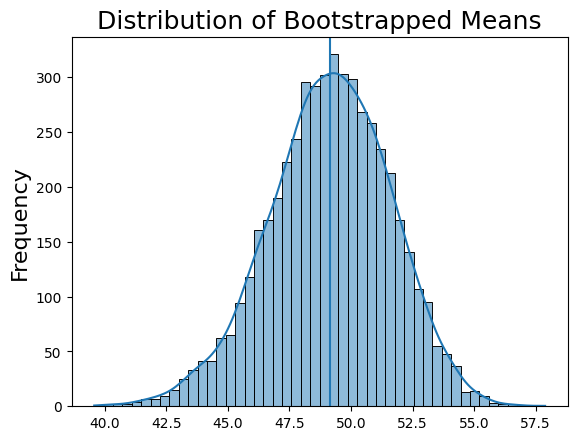

In [14]:
n_bootstrap = 5000

bootstrap_means = []
for b in range(n_bootstrap):
    bootstrap_means.append(np.mean(np.random.choice(sample, size=sample_n, replace=True)))
bootstrap_means = np.array(bootstrap_means)

sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
plt.axvline(x=np.mean(bootstrap_means), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Bootstrapped Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Bootstrapped Mean: {np.mean(bootstrap_means):.3}')
print(f'Bootstrapped Std: {np.std(bootstrap_means):.3}')

**Question**
What is the mean of the distribution of bootstrapped means? How close is it to the population mean of our simulated population?  Is this the result you expected?  Why?




How confident are we in the precision of our estimated mean? In other words, if we were to look through all 5,000 of our subsamples, how many of them would be close to 50.0? We can define a confidence interval to describe our uncertainty in our estimate. For example, we can use the percentile method to demonstrate the range of the estimated parameter in 95% of our samples. To do this we compute the upper and lower quantiles of our bootstrap estimates centered at 50% (i.e., 2.5% & 97.5%).

Bootstrapped Mean: 49.1
95% Confidence Intervals: [44.1, 53.7]


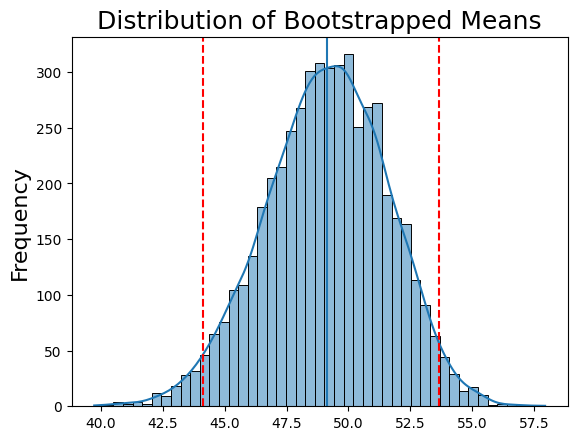

In [15]:
n_bootstrap = 5000

bootstrap_means = []
for b in range(n_bootstrap):
    bootstrap_means.append(np.mean(np.random.choice(sample, size=sample_n, replace=True)))
bootstrap_means = np.array(bootstrap_means)

sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
plt.axvline(x=np.mean(bootstrap_means), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Bootstrapped Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

plt.axvline(x=lower_bound, ymin=0, ymax=1, color='red', linestyle='--')
plt.axvline(x=upper_bound, ymin=0, ymax=1, color='red', linestyle='--')

print(f'Bootstrapped Mean: {np.mean(bootstrap_means):.3}')
print(f'95% Confidence Intervals: [{lower_bound:.3}, {upper_bound:.3}]')

*Question*:  How do we interpret this confidence interval?

While the percentile method is easy to compute and intuitive to understand, it has some issues. First, if the original sample was small and not representative of the population, the confidence interval may be biased and too narrow. Second, if the bootstrapped distribution is not symmetric and is skewed, the percentile based confidence intervals will not accurately reflect the distribution.

Now let’s see how the bootstrap compares to if we had run real independent experiments. Let’s simulate 1000 experiments where we randomly sample independent participants from the population and examine the distribution of the means from these independent experiments.

Bootstrapped Mean: 50.0
95% Confidence Intervals: [45.3, 54.4]


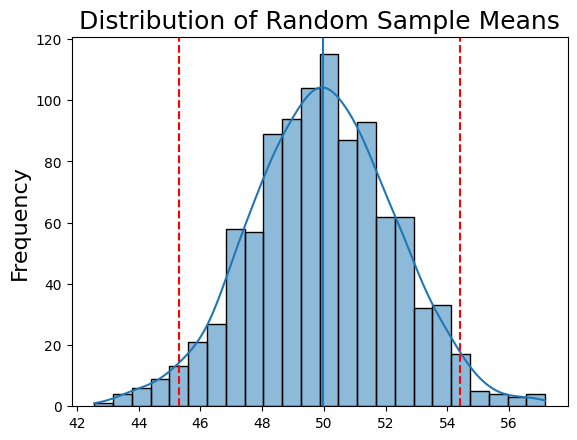

In [7]:
n_samples = 1000

sample_means = []
for b in range(n_samples):
    sample_means.append(np.mean(np.random.choice(population, size=sample_n, replace=False)))
sample_means = np.array(sample_means)

sns.histplot(sample_means, kde=True, label='Random Samples')
plt.axvline(x=np.mean(sample_means), ymin=0, ymax=1, linestyle='-')
plt.title('Distribution of Random Sample Means', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

lower_bound = np.percentile(sample_means, 2.5)
upper_bound = np.percentile(sample_means, 97.5)

plt.axvline(x=lower_bound, ymin=0, ymax=1, color='red', linestyle='--')
plt.axvline(x=upper_bound, ymin=0, ymax=1, color='red', linestyle='--')

print(f'Bootstrapped Mean: {np.mean(sample_means):.3}')
print(f'95% Confidence Intervals: [{lower_bound:.3}, {upper_bound:.3}]')

We see that the mean is closer to the population mean, but our certainty is approximately equal to what we estimated from bootstrapping a single sample.

Finally, let’s compare the bootstrapped distribution of 20 samples to the 1000 random samples

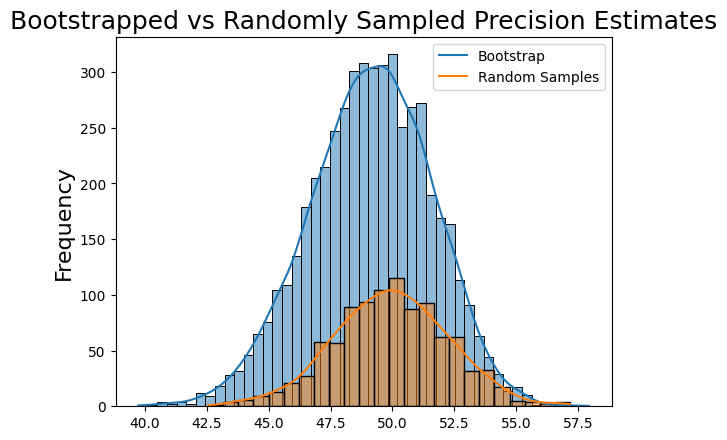

In [8]:
sns.histplot(bootstrap_means, kde=True, label='Bootstrap')
sns.histplot(sample_means, kde=True, label='Random Samples')
plt.title('Bootstrapped vs Randomly Sampled Precision Estimates', fontsize=18)
plt.ylabel('Frequency', fontsize=16)
plt.legend(['Bootstrap', 'Random Samples'])

**Variation/Active Learning Class Activity**:  Repeat the analysis above with:

1.  10% of the population used as the sample.
2.  Estimating the median rather than the mean.

#2.  Jackknife Resampling

The jackknife is your go-to when you need something quick and efficient, while the bootstrap is perfect when you want deep insights into your data, albeit at a higher computational cost.

At its core, the jackknife is like systematically peeking at your dataset from slightly different angles. It’s a leave-one-out technique, where you create multiple subsets of data by leaving out one observation at a time.



 Instead of randomly selecting samples, you methodically remove one observation and calculate the statistic of interest — like the mean or variance — for each subset. Think of it as peeling away one layer of an onion at a time to see how each layer impacts the whole.

Jackknife resampling logic:

1. You have a dataset of nnn observations.


1.   The jackknife creates nnn different subsamples, each leaving out one observation.
2.   For each subsample, you calculate your desired statistic (e.g., the mean, median, or regression coefficient).


1.   Finally, you average the estimates from all subsamples to get your jackknife estimator.
2.   This estimator helps you understand the bias or variance of your statistic without relying on any complex assumptions about the data’s distribution


**When to use it**

1.   Working with small data sets
2.   Need a quick computationally efficient method

 It’s not suited for highly variable datasets or complex models.



Let's reuse `sample` from the prior analysis.

Sample Mean: 49.1
Sample Std: 10.9


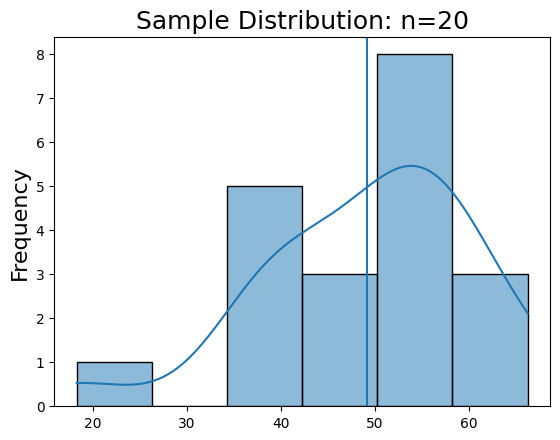

In [9]:
sns.histplot(sample, kde=True, label='Single Sample')
plt.axvline(x=np.mean(sample), ymin=0, ymax=1, linestyle='-')
plt.title(f'Sample Distribution: n={sample_n}', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Sample Mean: {np.mean(sample):.3}')
print(f'Sample Std: {np.std(sample):.3}')

This code systematically leaves out one data point at a time, calculates the mean of each subsample, and then estimates the overall jackknife mean, bias, and variance.

In [10]:
# Function to calculate the jackknife resampling mean
def jackknife_resampling(sample):
    n = sample_n
    jackknife_means = np.zeros(n)

    # Leave-one-out resampling
    for i in range(n):
        jackknife_sample = np.delete(sample, i)
        jackknife_means[i] = np.mean(jackknife_sample)

    # Jackknife estimator (mean of the means)
    jackknife_mean = np.mean(jackknife_means)

    # Bias estimation
    original_mean = np.mean(sample)
    bias = (n - 1)*(original_mean - jackknife_mean)
    #print(f'Bias: {bias}')

    # Variance estimation
    variance = (n - 1) * np.mean((jackknife_means - jackknife_mean) ** 2)

    return jackknife_mean, bias, variance, jackknife_means

mean, bias, variance, jackknife_means = jackknife_resampling(sample)
print(f"Jackknife Mean: {mean}")
print(f"Bias: {bias}")
print(f"Variance: {variance}")

Jackknife Mean: 49.138009884581265
Bias: 0.0
Variance: 6.3105088681578385


Jackknife Mean: 49.1
Jackknife Std: 0.576


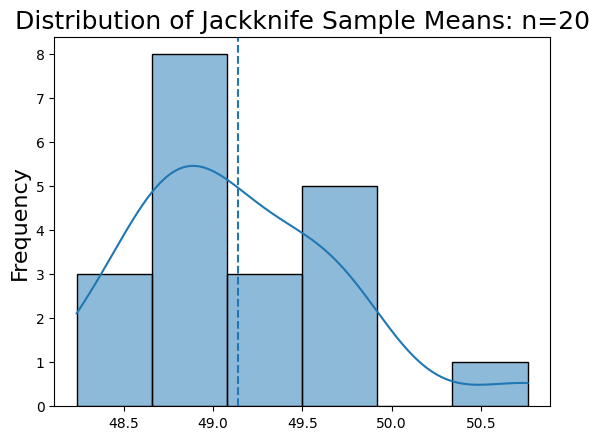

In [11]:
sns.histplot(jackknife_means, kde=True, label='Means of Jackknife Samples')
plt.axvline(x=np.mean(jackknife_means), ymin=0, ymax=1, linestyle='--')
plt.title(f'Distribution of Jackknife Sample Means: n={sample_n}', fontsize=18)
plt.ylabel('Frequency', fontsize=16)

print(f'Jackknife Mean: {np.mean(jackknife_means):.3}')
print(f'Jackknife Std: {np.std(jackknife_means):.3}')